<a href="https://colab.research.google.com/github/faisu6339-glitch/Machine-learning/blob/main/Revision(Supervise_ML_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [525]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [526]:
df=pd.read_csv("german_credit_data.csv")

In [527]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [528]:

# Add Risk column (0 = Good, 1 = Bad)
np.random.seed(42)
df['Risk'] = np.random.choice([0, 1], size=len(df), p=[0.7, 0.3])

# Save updated file
df.to_csv("german_credit_with_risk.csv", index=False)

print("Risk ")

Risk 


In [529]:
if df['Risk'].dtype == 'object':
    df['Risk'] = df['Risk'].map({'good':0, 'bad':1})

df['Risk'].value_counts()

,count
Risk,
0,712
1,288


In [530]:
df['Sex']

,Sex
0,male
1,female
2,male
3,male
4,male
...,...
995,female
996,male
997,male
998,male


In [531]:
df['Sex'].value_counts()

,count
Sex,
male,690
female,310


In [532]:
df['Housing'].value_counts()

,count
Housing,
own,713
rent,179
free,108


In [533]:
df['Saving accounts'].value_counts()

,count
Saving accounts,
little,603
moderate,103
quite rich,63
rich,48


In [534]:
df['Checking account'].value_counts()

,count
Checking account,
little,274
moderate,269
rich,63


In [535]:
df['Purpose'].value_counts()

,count
Purpose,
car,337
radio/TV,280
furniture/equipment,181
business,97
education,59
repairs,22
domestic appliances,12
vacation/others,12


In [536]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [537]:
df.isnull().mean()*100

,0
Unnamed: 0,0.0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,18.3
Checking account,39.4
Credit amount,0.0
Duration,0.0
Purpose,0.0


In [538]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

#Univariate Analysis

Age

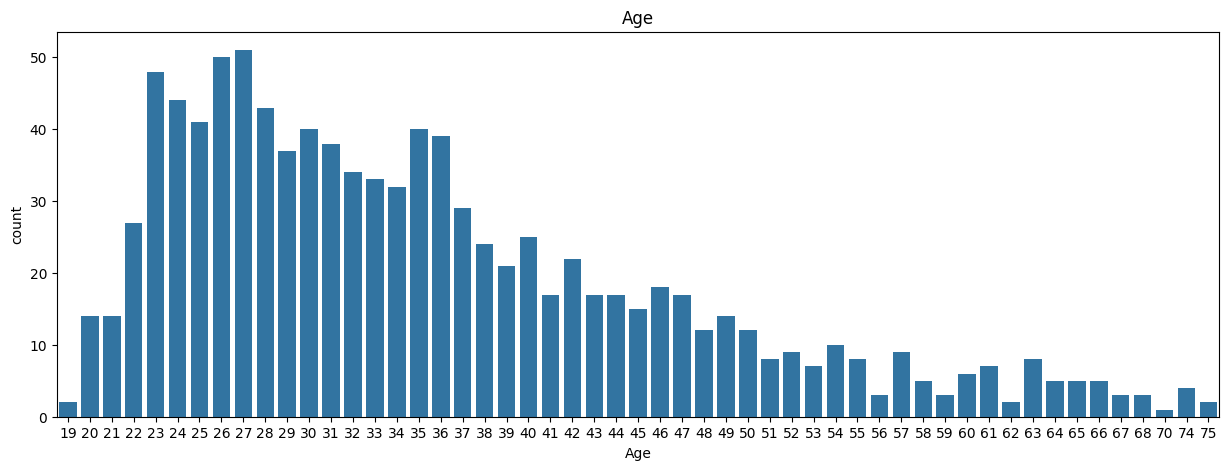

In [539]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Age')
plt.title('Age')
plt.show()

Sex

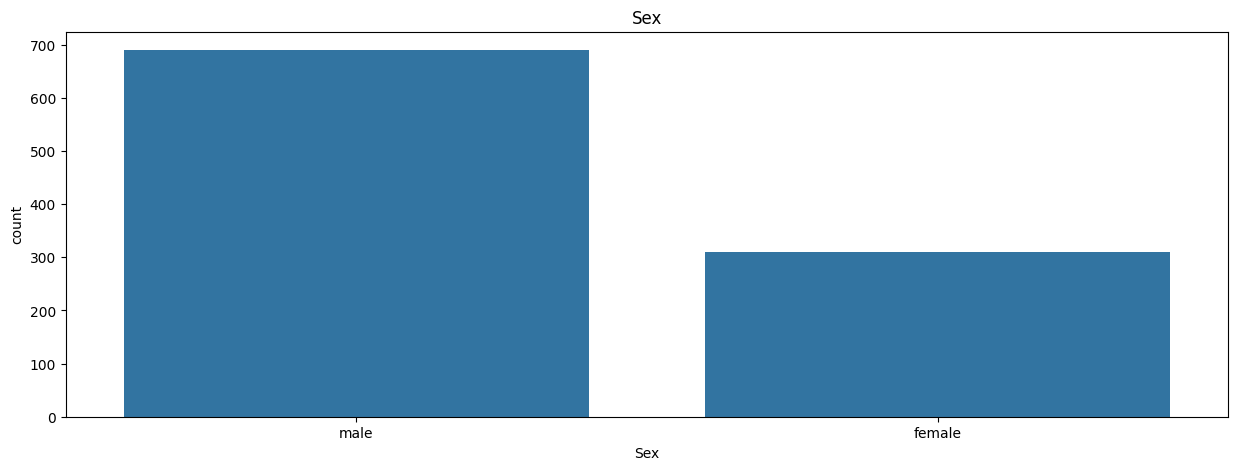

In [540]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Sex')
plt.title('Sex')
plt.show()

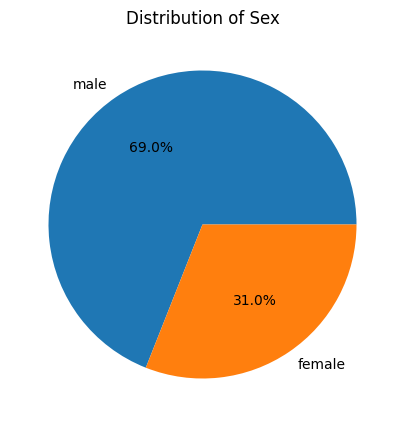

In [541]:
import matplotlib.pyplot as plt

df['Sex'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5))
plt.ylabel('')
plt.title('Distribution of Sex')
plt.show()

Housing

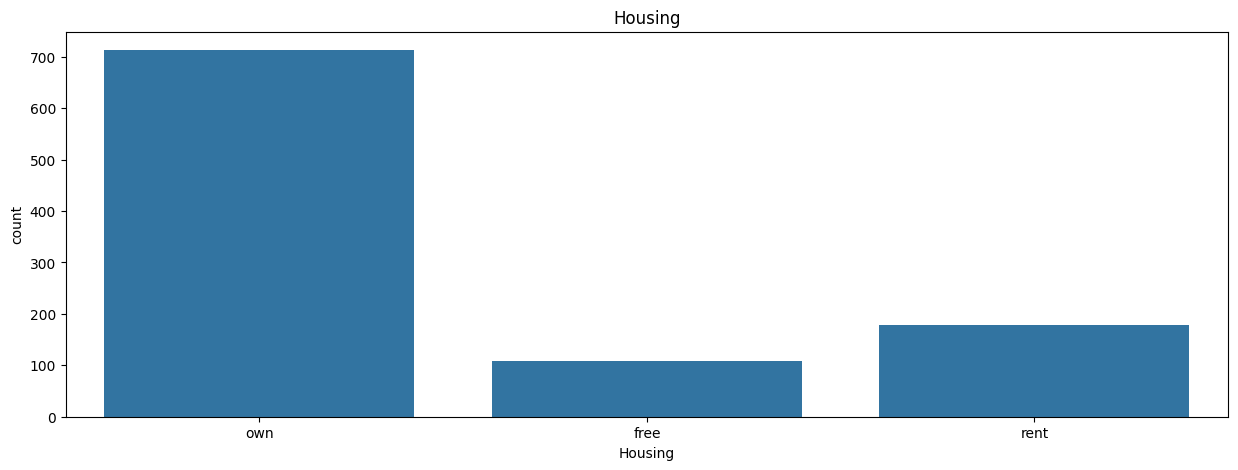

In [542]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Housing')
plt.title('Housing')
plt.show()

Saving Accounts

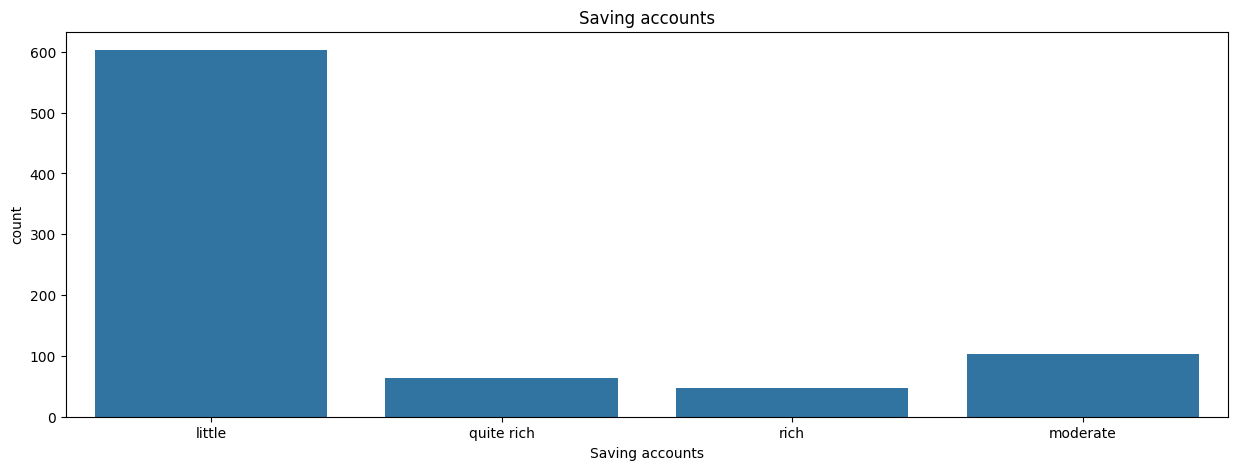

In [543]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Saving accounts')
plt.title('Saving accounts')
plt.show()

Checking Account

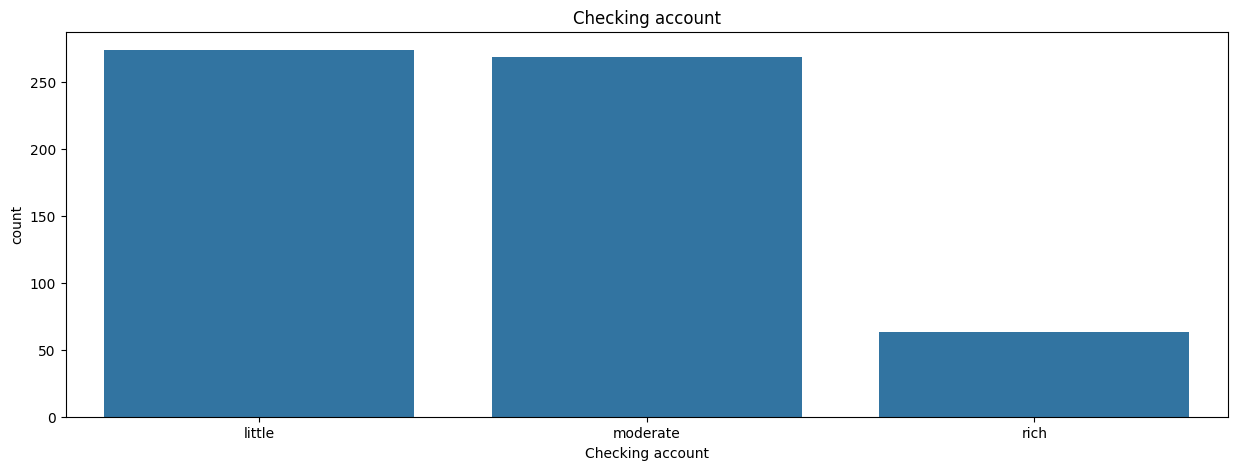

In [544]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Checking account')
plt.title('Checking account')
plt.show()

Purpose

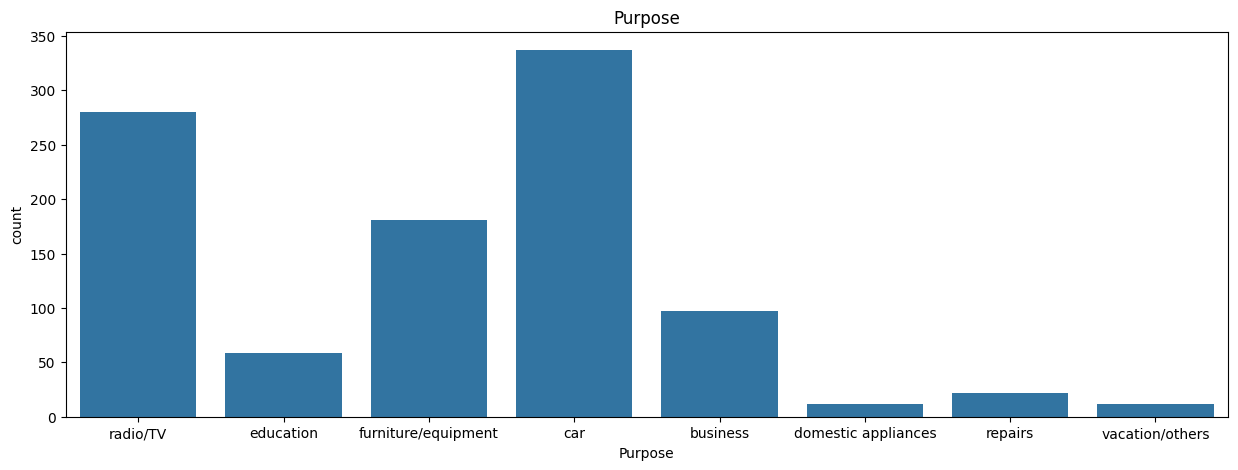

In [545]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Purpose')
plt.title('Purpose')
plt.show()

Job

Text(0.5, 1.0, 'Jobs')

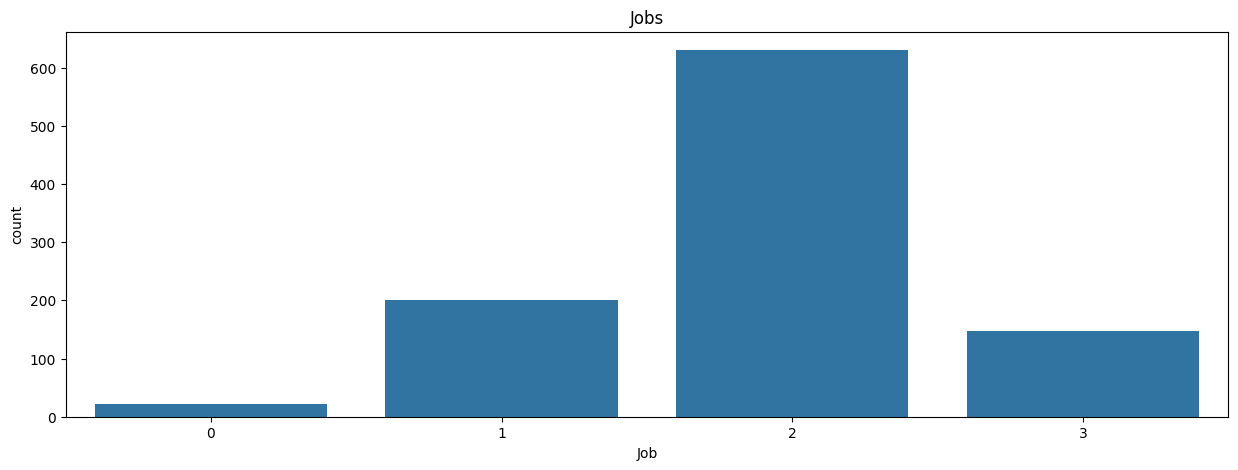

In [546]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Job')
plt.title('Jobs')

#Bivariate Analysis

Before Bivariate Analysis First we have to Difference between num_cols and cat_cols

In [547]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [548]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,4,53,male,2,free,little,little,4870,24,car,0


In [549]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns

In [550]:
num_cols

Index(['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration', 'Risk'], dtype='object')

In [551]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [552]:
print("Numerical Columns:",len(num_cols))
print("Categorical Columns:",len(cat_cols))

Numerical Columns: 6
Categorical Columns: 5


#Numerical Columns

In [553]:
df = df.drop(columns=['Unnamed: 0'])

In [554]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,0


In [555]:
num_cols

Index(['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration', 'Risk'], dtype='object')

In [556]:
import plotly.express as px
fig=px.box(df,x='Age',y='Credit amount',color='Sex')
fig.show()

In [557]:
fig = px.scatter(df, x='Age', y='Credit amount',
                 trendline='ols',
                 title='Age vs Credit Amount')
fig.show()

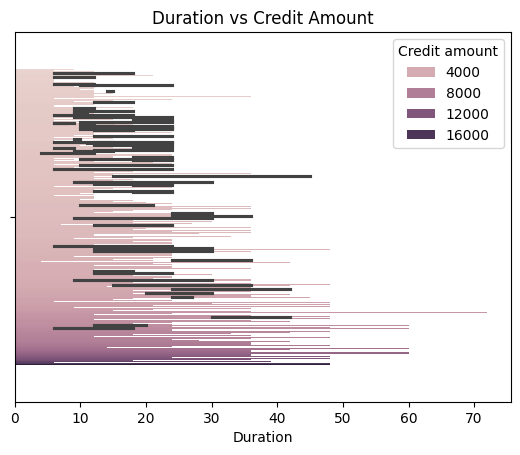

In [558]:
sns.barplot(data=df,x='Duration',hue='Credit amount')
plt.title('Duration vs Credit Amount')
plt.show()

In [559]:
px.scatter(df, x='Duration', y='Credit amount', trendline='ols')

In [560]:
import plotly.express as px
fig=px.box(df,x='Job',y='Duration',color='Sex')
fig.show()

In [561]:
fig = px.histogram(df, x='Sex', color='Housing',
                   barmode='group',
                   title='Sex vs Housing')
fig.show()

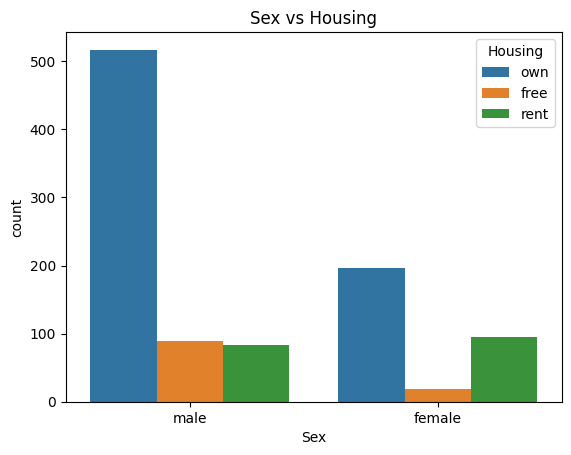

In [562]:
sns.countplot(data=df,x='Sex',hue='Housing')
plt.title('Sex vs Housing')
plt.show()

In [563]:
px.histogram(df, x='Purpose', color='Housing', barmode='group')

In [564]:
px.histogram(df, x='Job', color='Sex', barmode='group')

In [565]:
px.histogram(df, x='Job', color='Credit amount', barmode='group')

In [566]:
corr = df[['Age','Credit amount','Duration']].corr()

fig = px.imshow(corr, text_auto=True,
                title='Correlation Heatmap')
fig.show()

In [567]:
df.isnull().mean()*100

,0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,18.3
Checking account,39.4
Credit amount,0.0
Duration,0.0
Purpose,0.0
Risk,0.0


In [568]:
df['Saving accounts'].value_counts()

,count
Saving accounts,
little,603
moderate,103
quite rich,63
rich,48


#Label Encoder

In [569]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Housing']=le.fit_transform(df['Housing'])
df['Saving accounts'] = le.fit_transform(df['Saving accounts'])
df['Checking account'] = le.fit_transform(df['Checking account'])
df['Purpose'] = le.fit_transform(df['Purpose'])


In [570]:
df[['Sex']].head()
df['Sex'].unique()

array([1, 0])

In [571]:
df['Housing'].head()

,Housing
0,1
1,1
2,1
3,0
4,0


In [572]:
df['Housing'].unique()

array([1, 0, 2])

In [573]:
X = df.drop('Risk', axis=1)
y = df['Risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [574]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['Sex','Housing','Saving accounts','Checking account','Purpose']
numeric_cols = ['Age','Credit amount','Duration','Job']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [575]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


#Filling Missing Values

In [576]:
df['Saving accounts'] = df['Saving accounts'].fillna('No account')
df['Checking account'] = df['Checking account'].fillna('No account')

In [577]:
#df['Saving accounts'].fillna(df['Saving accounts'].mode()[0], inplace=True)


In [578]:
#df['Checking account'].fillna(df['Checking account'].mode()[0], inplace=True)

In [579]:
df.isnull().mean()*100

,0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,0.0
Checking account,0.0
Credit amount,0.0
Duration,0.0
Purpose,0.0
Risk,0.0


In [580]:
df['Saving accounts'].value_counts()
df['Checking account'].value_counts()

,count
Checking account,
3,394
0,274
1,269
2,63


#Preprocessing Techniques

In [581]:
print(df.columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [582]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,0
1,22,0,2,1,0,1,5951,48,5,1
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,0
4,53,1,2,0,0,0,4870,24,1,0


In [583]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [584]:
num_cols = ['Age','Job', 'Credit amount', 'Duration']

cat_cols = ['Sex', 'Housing',
            'Saving accounts', 'Checking account', 'Purpose']

In [585]:
num_cols = ['Age', 'Job','Credit amount', 'Duration']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} Outliers: {len(outliers)}")

Age Outliers: 23
Job Outliers: 370
Credit amount Outliers: 72
Duration Outliers: 70


In [586]:
num_cols = ['Age','Job', 'Credit amount', 'Duration']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nOutliers in {col}")
    print(outliers[[col]].head())   # show first few


Outliers in Age
     Age
0     67
75    66
137   66
163   70
179   65

Outliers in Job
   Job
2    1
5    1
7    3
8    1
9    3

Outliers in Credit amount
    Credit amount
5            9055
17           8072
18          12579
57           9566
63          14421

Outliers in Duration
    Duration
1         48
11        48
29        60
35        45
36        48


In [587]:
import plotly.express as px

num_cols = ['Age','Job', 'Credit amount', 'Duration']

for col in num_cols:
    fig = px.box(df, y=col, title=f'Outliers in {col}')
    fig.show()

In [588]:
num_cols = ['Age', 'Credit amount', 'Duration']

In [589]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [590]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [591]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,2.766456,1,2,1,4,0,-0.745131,-1.236478,5,0
1,-1.191404,0,2,1,0,1,0.949817,2.248194,5,1
2,1.183312,1,1,1,0,3,-0.416562,-0.738668,3,1
3,0.831502,1,2,0,0,0,1.634247,1.750384,4,0
4,1.535122,1,2,0,0,0,0.566664,0.256953,1,0


In [592]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,2.766456,1,2,1,4,0,-0.745131,-1.236478,5,0
1,-1.191404,0,2,1,0,1,0.949817,2.248194,5,1
2,1.183312,1,1,1,0,3,-0.416562,-0.738668,3,1
3,0.831502,1,2,0,0,0,1.634247,1.750384,4,0
4,1.535122,1,2,0,0,0,0.566664,0.256953,1,0


In [593]:
X = df.drop('Risk', axis=1)
y = df['Risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [594]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [595]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

In [596]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.58
              precision    recall  f1-score   support

           0       0.70      0.73      0.71       142
           1       0.25      0.22      0.24        58

    accuracy                           0.58       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.57      0.58      0.57       200



In [597]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [5,10,15,None],
    'classifier__min_samples_split': [2,5,10],
    'classifier__min_samples_leaf': [1,2,4]
}

grid = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Tuned Decision Tree Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.72      0.96      0.82       142
           1       0.40      0.07      0.12        58

    accuracy                           0.70       200
   macro avg       0.56      0.51      0.47       200
weighted avg       0.62      0.70      0.62       200



#Naive Bayes Pipeline

In [598]:
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

y_pred_nb = nb_pipeline.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.535
              precision    recall  f1-score   support

           0       0.74      0.53      0.62       142
           1       0.32      0.55      0.41        58

    accuracy                           0.54       200
   macro avg       0.53      0.54      0.51       200
weighted avg       0.62      0.54      0.56       200



In [599]:
from sklearn.metrics import roc_auc_score

y_prob = best_dt.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.5250728508984944


In [600]:
!pip install imbalanced-learn

In [601]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [602]:
print(y_train_smote.value_counts())

Risk
0    570
1    570
Name: count, dtype: int64


In [603]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.56
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       142
           1       0.21      0.19      0.20        58

    accuracy                           0.56       200
   macro avg       0.45      0.45      0.45       200
weighted avg       0.55      0.56      0.55       200



In [604]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

y_pred = best_dt.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.70      0.89      0.78       142
           1       0.20      0.07      0.10        58

    accuracy                           0.65       200
   macro avg       0.45      0.48      0.44       200
weighted avg       0.56      0.65      0.59       200



In [605]:
best_dt = grid.best_estimator_

In [606]:
dt_model = best_dt.named_steps['classifier']

AttributeError: 'DecisionTreeClassifier' object has no attribute 'named_steps'

# Task
Refactor the data preprocessing and model training pipeline by undoing premature `LabelEncoder` and `StandardScaler` applications. Reload the data, ensure the 'Risk' column is correctly set, and handle missing values before re-splitting the dataset. Implement a robust `ColumnTransformer` for numerical scaling and categorical one-hot encoding, and integrate it into `sklearn.pipeline.Pipeline` objects for both Decision Tree and Naive Bayes classifiers. Tune the Decision Tree pipeline using `GridSearchCV` and evaluate both models with appropriate metrics like accuracy, classification reports, and ROC AUC, ensuring correct model extraction.

## Clear In-Place LabelEncoder Calls

### Subtask:
Clear the code from cell `_O0xVJY0DdaJ` and `Tk0o0vLHAP-q` to prevent premature Label Encoding of categorical features, which will instead be handled by the `OneHotEncoder` within the ColumnTransformer pipeline.


**Reasoning**:
Clearing the content of cell `_O0xVJY0DdaJ` as per the subtask instructions to remove premature Label Encoding.



**Reasoning**:
Clearing the content of cell `_O0xVJY0DdaJ` as per the subtask instructions to remove premature Label Encoding.



**Reasoning**:
Clearing the content of cell `Tk0o0vLHAP-q` as per the subtask instructions to remove premature Label Encoding.



**Reasoning**:
Clearing the content of cell `Tk0o0vLHAP-q` as per the subtask instructions to remove premature Label Encoding.



**Reasoning**:
Clearing the content of cell `Tk0o0vLHAP-q` as per the subtask instructions to remove premature Label Encoding.



**Reasoning**:
Clearing the content of cell `Tk0o0vLHAP-q` as per the subtask instructions to remove premature Label Encoding.



**Reasoning**:
The previous code identified 'Job' as a numerical column, but it should be treated as categorical for the `ColumnTransformer`. This step updates the `num_cols` list to exclude 'Job', ensuring correct preprocessing later.



In [607]:
num_cols = ['Age', 'Credit amount', 'Duration']

print("Updated numerical columns:", num_cols)

Updated numerical columns: ['Age', 'Credit amount', 'Duration']


**Reasoning**:
The previous identification of categorical columns (`cat_cols`) was missing 'Job', which was incorrectly placed in `num_cols`. This step updates the `cat_cols` list to include 'Job' as a categorical feature, ensuring all categorical features are properly identified for subsequent preprocessing.



In [608]:
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Job']

print("Updated categorical columns:", cat_cols)

Updated categorical columns: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Job']


**Reasoning**:
The `preprocessor` needs to be updated with the newly defined `num_cols` and `cat_cols` to ensure that 'Job' is treated as a categorical feature and only actual numerical columns are scaled.



In [609]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

print("ColumnTransformer updated with correct numeric and categorical columns.")

ColumnTransformer updated with correct numeric and categorical columns.


**Reasoning**:
The previous operations prematurely applied `LabelEncoder` and `StandardScaler` on the `df`. To ensure a clean pipeline, the dataset needs to be reloaded to its state after the 'Risk' column was added and before any preprocessing, then handle missing values, and finally redefine `X` and `y` and split the data.



In [610]:
df = pd.read_csv('german_credit_with_risk.csv')

# Drop the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Handle missing values as done previously
df['Saving accounts'] = df['Saving accounts'].fillna('No account')
df['Checking account'] = df['Checking account'].fillna('No account')

# Redefine X and y
X = df.drop('Risk', axis=1)
y = df['Risk']

# Re-split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data reloaded, missing values handled, and data re-split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Data reloaded, missing values handled, and data re-split into training and testing sets.
X_train shape: (800, 9), y_train shape: (800,)
X_test shape: (200, 9), y_test shape: (200,)
